In [1]:
import sys, os, importlib
import functions
importlib.reload(functions)
from functions import *
import glob
import matplotlib.pyplot as plt

In [2]:
#import data
file_name="../DATA/SN2010ev.fits"#"unzappedSN2010ev.fits"
    
    
data = fits.open(file_name)
cube = data[1].data   # this is the cube, a (3681 x 341 x 604) matrix with fluxes at different 3681 wavelengths and 308 x 318 spatial pixels ("spaxels")
header = data[1].header # this has information on the data cube
ecube = data[2].data # this is the cube uncertainty (3681 x 341 x 604)
print(np.shape(cube))


x_len=len(cube[0][0])
y_len=len(cube[0])

#  -- following is to the get the wavelength array
CRVAL = float(header["CRVAL3"])
NAXIS = int(header["NAXIS3"])
CDELT = float(header["CD3_3"])
CRPIX = float(header["CRPIX3"])
wave = np.array(CRVAL + CDELT * (np.arange(NAXIS) - CRPIX))

(3681, 341, 604)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

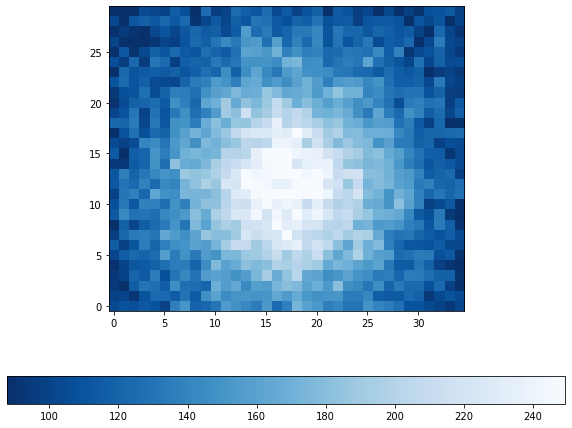

In [19]:
na_rest=(5890+5896)/2

index=findWavelengths(wave, na_rest)[1]

region=cube[:,170:200,290:325]
image=region[index]
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
#plt.title("PCA second component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")

#new_wave,cropped_cube=chop_data(wave,region,na_rest-100,na_rest+100)
new_wave,cropped_cube=chop_data(wave,cube,na_rest-100,na_rest+100)

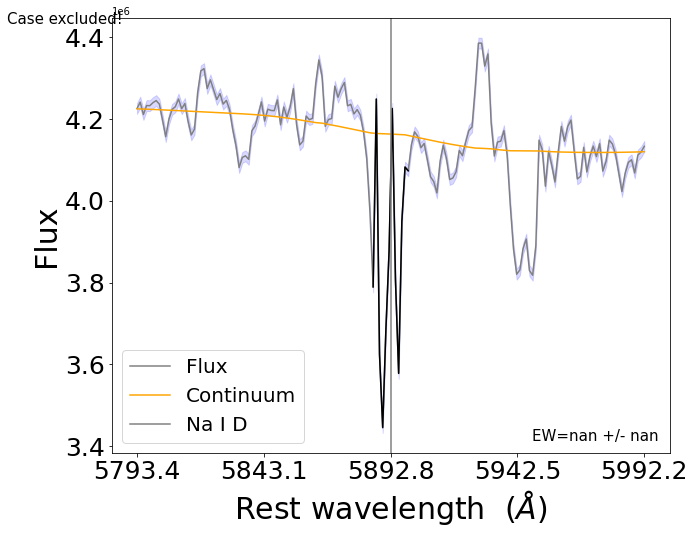


EW= nan  +/-  nan

Node separation =  142.98561151079136  Angstrom
SNR of the line is  nan


([nan], [nan], [7279.091032281929])

In [20]:
spectrum = np.nansum(cropped_cube[:,:,:], axis=(1, 2))
EW_voronoi_bins(np.array([spectrum]),new_wave,na_rest,v=400,KS=100,plots=True)

In [69]:
normalization=False

In [71]:
n_wave, ny, nx = cropped_cube.shape
X = cropped_cube.reshape(n_wave, ny * nx).T

mask = np.isfinite(X).all(axis=1) #masking NaNs
X_clean = X[mask]

if normalization==True:
    mean_spec = np.nanmean(X_clean, axis=0)
    X_clean = X_clean - mean_spec

In [75]:
"""scaler = StandardScaler() #transforms features so they all have a mean=0 and stddev=1 which helps PCA to treat all features equally
X_scaled = scaler.fit_transform(X_clean)"""
X_scaled=X_clean

n_components=2

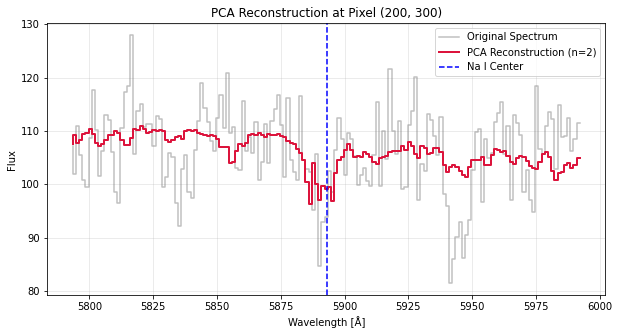

In [99]:
n_lambda, n_y, n_x = cropped_cube.shape
data_flattened = cropped_cube.reshape(n_lambda, -1).T 

# Handle NaNs (PCA cannot handle them)
data_flattened = np.nan_to_num(data_flattened)

# 2. Apply PCA with 2 components
pca = PCA(n_components=2)
components = pca.fit_transform(data_flattened)

# 3. Reconstruct the data from the 2 components
reconstructed_flattened = pca.inverse_transform(components)

# 4. Reshape back to the original cube dimensions
reconstructed_cube = reconstructed_flattened.T.reshape(n_lambda, n_y, n_x)

y_coord, x_coord = 200, 300

# Extract spectra
original_spec = cropped_cube[:, y_coord, x_coord]
reconstructed_spec = reconstructed_cube[:, y_coord, x_coord]

# Plotting
plt.figure(figsize=(10, 5))
plt.step(new_wave, original_spec, label='Original Spectrum', color='gray', alpha=0.5)
plt.step(new_wave, reconstructed_spec, label='PCA Reconstruction (n=2)', color='crimson', lw=2)

plt.axvline(na_rest, color='blue', linestyle='--', label='Na I Center')
plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux')
plt.title(f'PCA Reconstruction at Pixel ({y_coord}, {x_coord})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

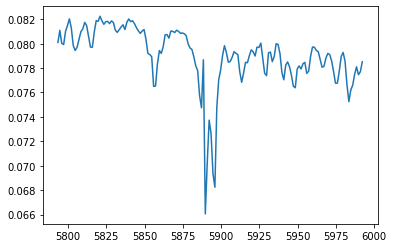

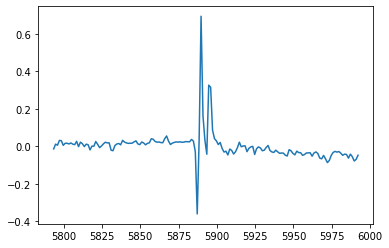

In [95]:
plt.plot(new_wave,pca.components_[0])
plt.show()
plt.plot(new_wave,pca.components_[1])

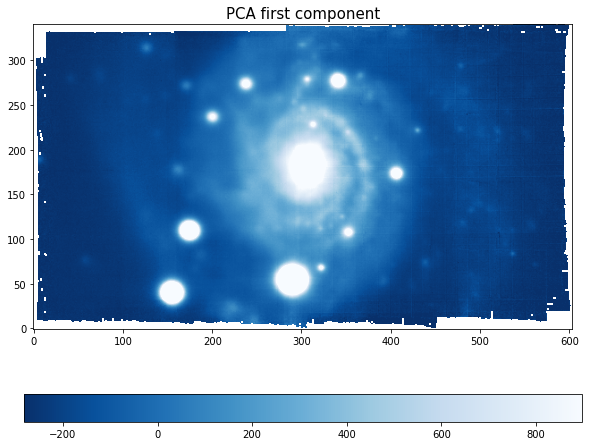

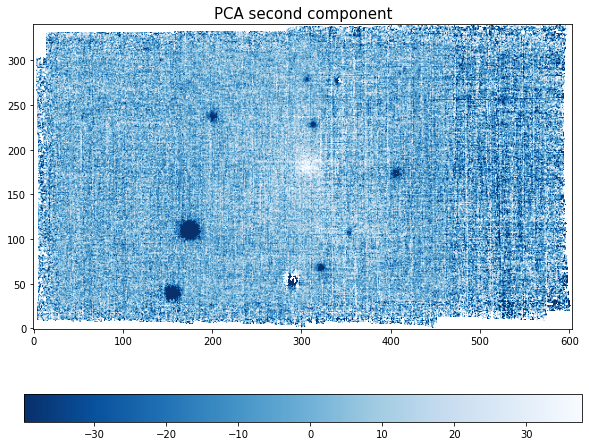

In [96]:
pc1_map = np.full(ny * nx, np.nan)
pc1_map[mask] = X_pca[:, 0]
pc1_map = pc1_map.reshape(ny, nx)

image=pc1_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA first component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")


pc1_map = np.full(ny * nx, np.nan)
pc1_map[mask] = X_pca[:, 1]
pc1_map = pc1_map.reshape(ny, nx)

image=pc1_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA second component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")

# PCA

components_ are the basis vectors (spectra)

fit_transform are the coefficients for each spaxel

In [76]:
#applying PCA algorithm
pca = PCA(n_components)
X_pca = pca.fit_transform(X_scaled)

In [77]:
#eigenspectra
eigenspectra = pca.components_



print(np.shape(pca.components_),"\n\n ",pca.explained_variance_ratio_,"\n\n ",np.shape(pca.mean_),"\n\n ",np.shape(pca.singular_values_))

(2, 160) 

  [9.94697888e-01 2.06298370e-04] 

  (160,) 

  (2,)


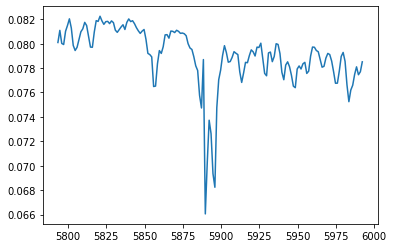

In [78]:
np.shape(pca.components_[0])
plt.plot(new_wave,pca.components_[0])

In [79]:
np.shape(X_pca)

(194518, 2)

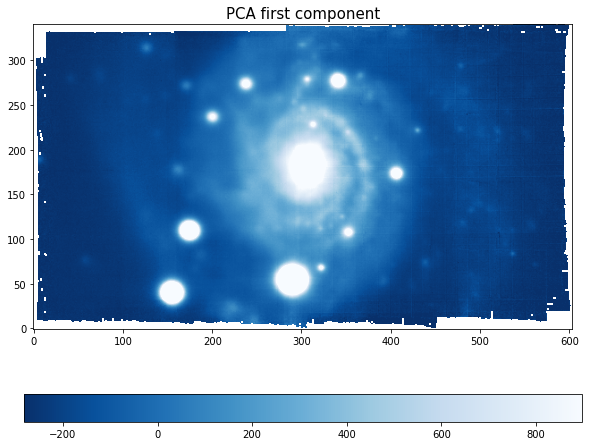

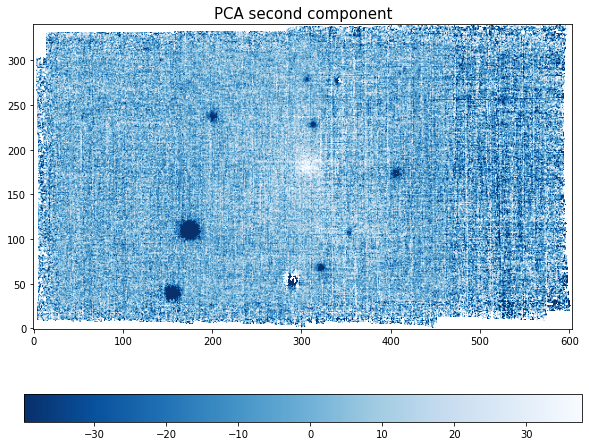

In [80]:
pc1_map = np.full(ny * nx, np.nan)
pc1_map[mask] = X_pca[:, 0]
pc1_map = pc1_map.reshape(ny, nx)

image=pc1_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA first component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")


pc2_map = np.full(ny * nx, np.nan)
pc2_map[mask] = X_pca[:, 1]
pc2_map = pc2_map.reshape(ny, nx)

image=pc2_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA second component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")

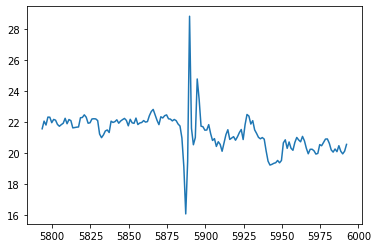

(80.0, 120.0)

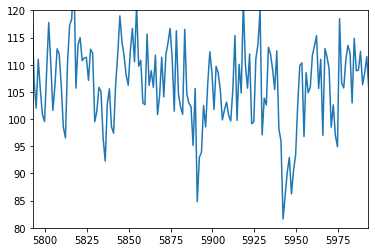

In [100]:
y=pca.mean_ + pca.components_[0]*pc1_map[200,300]+pca.components_[1]*pc2_map[200,300]

plt.plot(new_wave,y)
plt.show()
plt.plot(wave,cube[:,200,300])
plt.xlim(na_rest-100,na_rest+100)
plt.ylim(80,120)

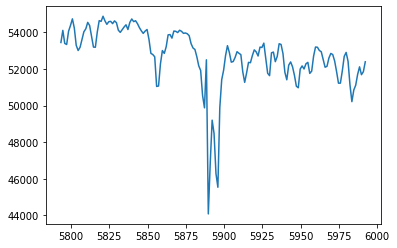

In [101]:
spectrum=pca.singular_values_[0]*pca.components_[0]#+pca.singular_values_[1]*pca.components_[1]
plt.plot(new_wave,spectrum)

#EW_voronoi_bins(np.array([spectrum]),new_wave,na_rest,v=400,KS=100,plots=True)

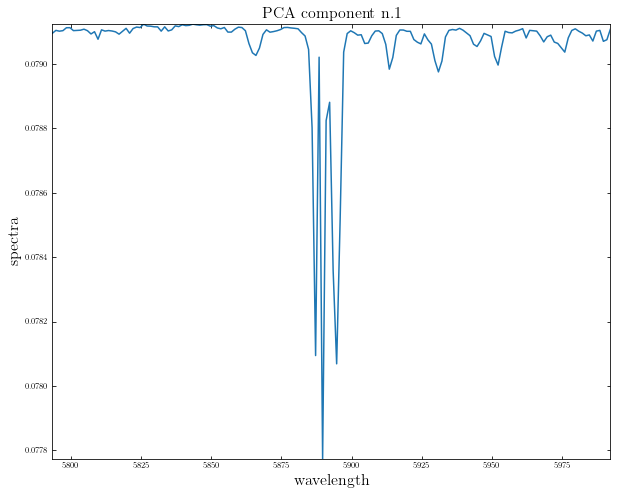

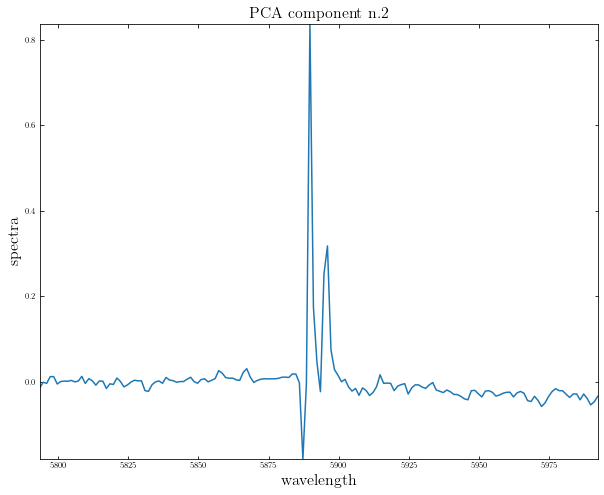

In [108]:
for i in range(0,len(eigenspectra)):
    
    plt.figure(figsize=(10, 8))
    plt.plot(new_wave,eigenspectra[i])
    
    plt.title(f"PCA component n.{i+1}",fontsize=16)
    plt.xlabel("wavelength",fontsize=16)
    plt.ylabel("spectra",fontsize=16)
    plt.show()


Text(0, 0.5, 'cumulative explained variance')

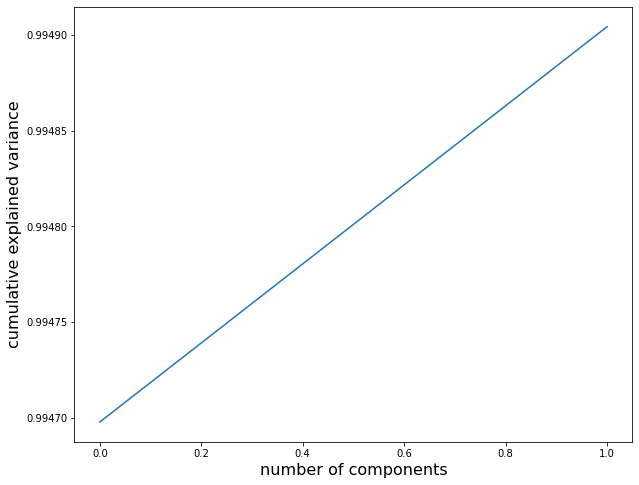

In [90]:
plt.figure(figsize=(10, 8))  
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components',fontsize=16)
plt.ylabel('cumulative explained variance',fontsize=16)

In [91]:
np.shape(pca.singular_values_)

(2,)

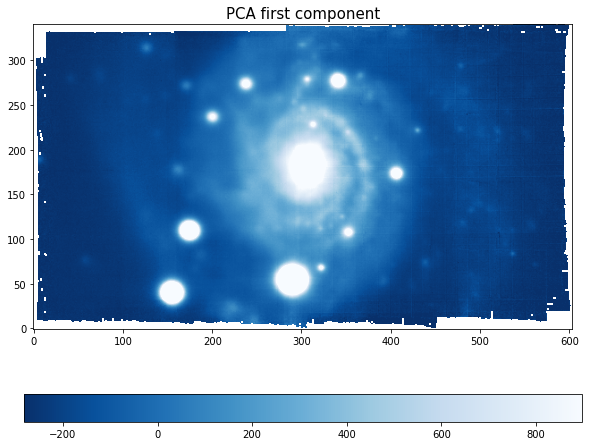

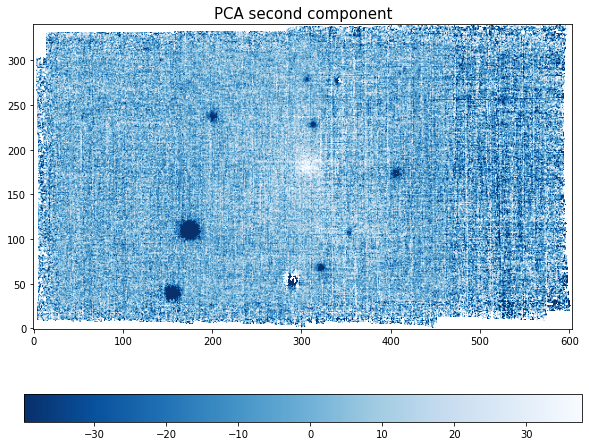

In [92]:
pc1_map = np.full(ny * nx, np.nan)
pc1_map[mask] = X_pca[:, 0]
pc1_map = pc1_map.reshape(ny, nx)

image=pc1_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA first component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")


pc1_map = np.full(ny * nx, np.nan)
pc1_map[mask] = X_pca[:, 1]
pc1_map = pc1_map.reshape(ny, nx)

image=pc1_map
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA second component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")

In [93]:
np.shape(X)

(205964, 160)

plotting the weighted spectra (component) at a given spaxel

In [25]:
region=cube[:,100:250,220:400]
"""image=region[i]
lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA first component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")"""

160

In [73]:
n_wave_used = pca.components_.shape[1]

X_pc1 = (
    pca.mean_[None, :] +
    X_pca[:, :2] @ pca.components_[:2]
)#(pca.mean_[None, :] + X_pca[:, 0][:, None] * pca.components_[0][None, :])#X_pca[:, 0][:, None] * pca.components_[0][None, :]

cube_pc1 = np.full((n_wave_used, ny * nx), np.nan)

cube_pc1[:, mask] = X_pc1.T

cube_pc1 = cube_pc1.reshape(n_wave_used, ny, nx)

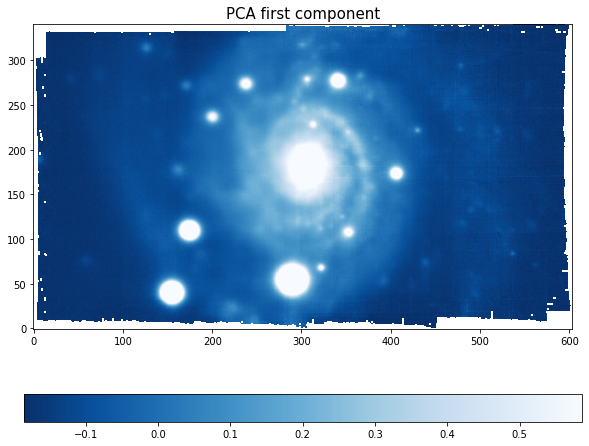

In [74]:
i=findWavelengths(new_wave, na_rest)[1]
image=cube_pc1[i]

lo,up = np.nanpercentile(image,2),np.nanpercentile(image,98)
plt.figure(figsize=(10, 8))
plt.title("PCA first component",fontsize=15)
plt.imshow(image,cmap='Blues_r',origin='lower',clim=(lo,up))
plt.colorbar(orientation="horizontal")

In [75]:
spectrum = np.nansum(cube_pc1[:,100:250,220:400], axis=(1, 2)) #HERE DO MEDIAN

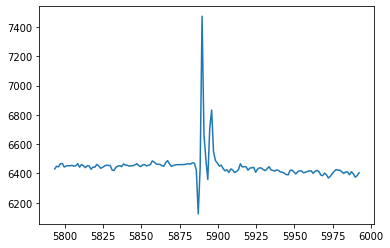

In [76]:
plt.plot(new_wave,spectrum)

# NMF

In [40]:
from sklearn.decomposition import NMF

# NMF requires non-negative data
X_nmf = X_clean.copy()
X_nmf[X_nmf < 0] = 0.0

nmf = NMF(n_components=4,init="nndsvda",
    max_iter=1000,random_state=0)

W = nmf.fit_transform(X_nmf)   # (n_spaxels, n_components)
H = nmf.components_            # (n_components, n_wave_used)

In [34]:
# plotting the precision score https://towardsdatascience.com/using-nmf-to-classify-companies-a77e176f276f/

err = np.linalg.norm(X_nmf - W @ H)**2/np.linalg.norm(X_nmf)**2
print(err)

0.001301843824213024


In [29]:
err = nmf.reconstruction_err_
err

23581.63895915634

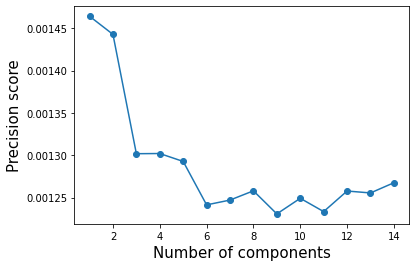

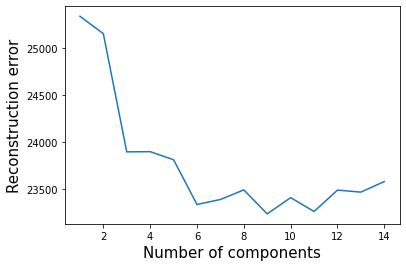

In [32]:
ks = range(1, 15)
errors = []
aux=[]
for k in ks:
    nmf = NMF(n_components=k, init="nndsvda", max_iter=1000, random_state=0)
    W = nmf.fit_transform(X_nmf)
    H = nmf.components_
    err = np.linalg.norm(X_nmf - W @ H)**2 / np.linalg.norm(X_nmf)**2 #precision score
    errors.append(err)
    aux.append(nmf.reconstruction_err_)

plt.plot(ks, errors, marker="o")
plt.xlabel("Number of components",fontsize=15)
plt.ylabel("Precision score",fontsize=15)
plt.show()

plt.plot(ks,aux)
plt.xlabel("Number of components",fontsize=15)
plt.ylabel("Reconstruction error",fontsize=15)
plt.show()


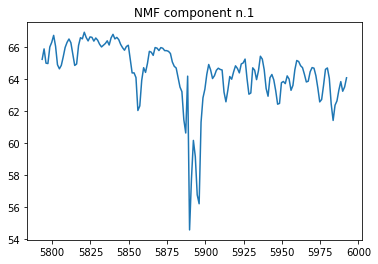

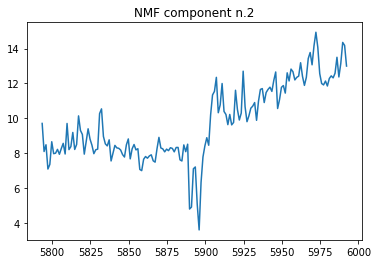

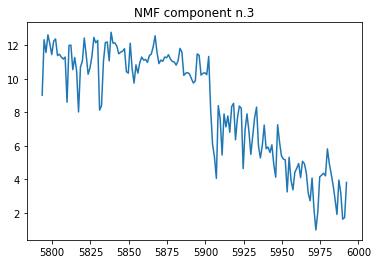

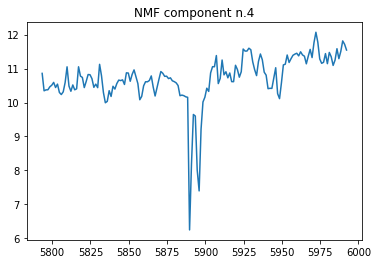

In [41]:
for k in range(H.shape[0]):
    plt.plot(new_wave, H[k], label=f"NMF {k+1}")
    plt.title(f"NMF component n.{k+1}")
    plt.show()


In [222]:
comp = 0
map_k = W[:, comp].reshape(ny, nx)

plt.imshow(map_k, origin="lower")
plt.colorbar(label="Weight")
plt.title(f"NMF component {comp+1}")
plt.show()

ValueError: cannot reshape array of size 194518 into shape (341,604)

# SVD

In [14]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=0)
X_svd = svd.fit_transform(X_scaled)

components = svd.components_   # (n_components, n_wave_used)
explained = svd.explained_variance_ratio_

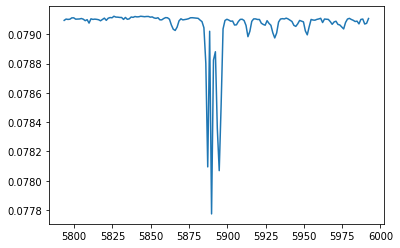

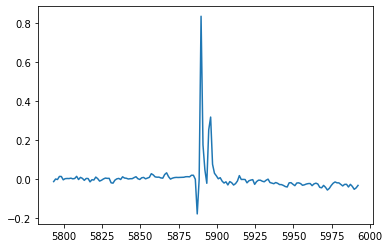

In [15]:
np.shape(components)
for i in range(0,len(components)):
    plt.plot(new_wave, components[i])
    plt.show()

# measuring EW from eigenspectra

# bootstrap for final EW measurement

In [266]:
import numpy as np
data=np.load("temp_EW_measurements.npy")

In [146]:
y=np.transpose(data)[0]
EW_errs=np.transpose(data)[1]
x=np.arange(0,len(y))

SNRs=np.divide(y,EW_errs)

In [147]:
sigma = np.array(EW_errs)

w = 1 / sigma**2

weighted_mean = np.sum(w * y) / np.sum(w)
mean_unc = np.sqrt(1 / np.sum(w))


weighted_std_dev = np.sqrt(np.sum(w * (y - weighted_mean)**2) / np.sum(w))
mean=np.mean(y)
mad = np.mean(np.abs(y - np.mean(y)))
median = np.median(y)
std = np.std(y, ddof=1) 

#std_dev = np.sqrt(np.sum((y -  weighted_mean)**2) / len(y))

In [148]:
weighted_mean
bootsample

array([0.78105959, 0.62564291, 0.46584909, 0.51499874, 0.47844998,
       0.54243836, 0.61002571, 0.59657109, 0.56311262, 0.47892138,
       0.59657109, 0.36323923, 0.47844998, 0.47844998, 0.50315015,
       0.50315015, 0.51499874, 0.44779861, 0.66318224, 0.50315015,
       0.56311262, 0.36323923, 0.54612955, 0.78105959, 0.66318224,
       0.54243836, 0.42676209, 0.49025984, 0.59657109, 0.54612955])

In [90]:
boot_means = []
for _ in range(10000):
    bootsample = np.random.choice(y,size=30, replace=True)
    boot_means.append(bootsample.mean())
    
    
bootmean = np.mean(boot_means)
bootmean_std = np.std(boot_means)

In [87]:
boot_means = []
for _ in range(10000):
    
    indices = np.random.choice(len(y), size=len(y), replace=True)
    y_sample = y[indices]
    sigma_sample = sigma[indices]
    w_sample = 1 / sigma_sample**2
    
    boot_mean = np.sum(w_sample * y_sample) / np.sum(w_sample)
    boot_means.append(boot_mean)

boot_means = np.array(boot_means)
bootmean = np.mean(boot_means)
bootmean_std = np.std(boot_means, ddof=1)

In [88]:
bootmean

0.49874179447632233

0.49899823074392663 0.01873282257409509


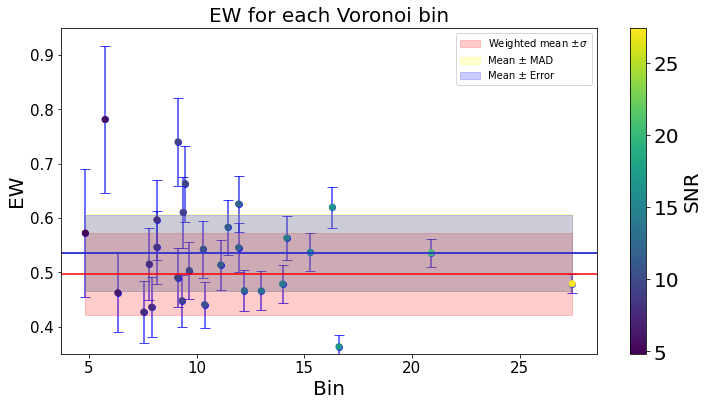

In [79]:
fig, ax = plt.subplots(figsize=(12, 6))

# scatter with colormap (this is what the colorbar must be attached to)
sc = ax.scatter(SNRs, y, c=SNRs, cmap='viridis', zorder=2)

ax.errorbar(
    SNRs, y, yerr=EW_errs,
    fmt='o', color='blue',
    alpha=0.75, capsize=5, zorder=1
)

# create ONE colorbar, tied to the scatter
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('SNR', fontsize=20)
cbar.ax.tick_params(labelsize=20)

ax.set_xlabel("Bin", fontsize=20)
ax.set_ylabel("EW", fontsize=20)
ax.set_title("EW for each Voronoi bin", fontsize=20)

ax.axhline(y=weighted_mean,color="red")
ax.fill_between([SNRs.min(), SNRs.max()],weighted_mean - weighted_std_dev,weighted_mean + weighted_std_dev,color='red',alpha=0.2,label=r'Weighted mean $\pm \sigma$')

ax.axhline(y=mean,color="yellow")
ax.fill_between([SNRs.min(), SNRs.max()],mean - mad,mean + mad,color='yellow',alpha=0.2,label='Mean ± MAD')

ax.axhline(y=median,color="blue")
ax.fill_between([SNRs.min(), SNRs.max()],median - mad,median + mad,color='blue',alpha=0.2,label='Mean ± Error')


print(boot_mean_val, boot_err)
ax.set_ylim(0.35, 0.95)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.legend()


In [92]:
print(f"The median is {median:.2f} +/- {mad:.2f} (mean absolute deviation)")
print(f"The mean is {mean:.2f} +/-  {std:.2f} (standard deviation)")
print(f"The weigthed mean is {weighted_mean:.2f} +/- {weighted_std_dev:.2f} (weigthed standard deviation)")
print(f"The bootstrap mean is {bootmean:.2f} +/- {bootmean_std:.2f} (standard deviation of bootstrap estimates)")

The median is 0.54 +/- 0.07 (mean absolute deviation)
The mean is 0.54 +/-  0.09 (standard deviation)
The weigthed mean is 0.50 +/- 0.08 (weigthed standard deviation)
The bootstrap mean is 0.54 +/- 0.02 (standard deviation of bootstrap estimates)


# Windwo and continuum studies

In [2]:
import numpy as np
data=np.load("temp_window_cont.npy")

wave, spectrum=np.transpose(data)


In [3]:
na_rest=(5890+5896)/2
best_KS=best_continuum(wave, spectrum, wavelength=na_rest,vel=400,plots=True,save="Best-continuum.pdf")



EW= 0.27  +/-  0.044853544666462436

Node separation =  29.444444444444446  Angstrom
SNR of the line is  5.920721375393585

EW= 0.30  +/-  0.05075751984505064

Node separation =  44.16666666666667  Angstrom
SNR of the line is  5.978843660910401

EW= 0.33  +/-  0.05132174433340707

Node separation =  58.88888888888889  Angstrom
SNR of the line is  6.363575527982117

EW= 0.34  +/-  0.05110192671576518

Node separation =  73.61111111111111  Angstrom
SNR of the line is  6.6908281853351

EW= 0.36  +/-  0.05170823196510022

Node separation =  88.33333333333334  Angstrom
SNR of the line is  6.910682559709672

EW= 0.37  +/-  0.05265492501814436

Node separation =  103.05555555555556  Angstrom
SNR of the line is  7.056306183253604

EW= 0.38  +/-  0.05373143823091684

Node separation =  117.77777777777779  Angstrom
SNR of the line is  7.106203210302466

EW= 0.39  +/-  0.05453597349779116

Node separation =  132.5  Angstrom
SNR of the line is  7.113462731258132

EW= 0.39  +/-  0.054953106540468


In [4]:
best_KS

100

In [292]:
wave[2]-wave[1]

1.25

In [293]:
best_KS

100

In [294]:
get_velocity_separation(100, wave[2]-wave[1], na_rest)

6359.079798065501

In [295]:

# inspect best window
best_window=best_integration_window(wave, spectrum, wavelength=na_rest,best_KS=best_KS,plots=True,save="Best-window.pdf")


EW= 0.21  +/-  0.15670718525209645

Node separation =  147.22222222222223  Angstrom
SNR of the line is  1.3453708593609983

EW= 0.21  +/-  0.15670718525209645

Node separation =  147.22222222222223  Angstrom
SNR of the line is  1.3453708593609983

EW= 0.25  +/-  0.1602027962066695

Node separation =  147.22222222222223  Angstrom
SNR of the line is  1.5375387388589157

EW= 0.25  +/-  0.09554365084939839

Node separation =  147.22222222222223  Angstrom
SNR of the line is  2.578067752817355

EW= 0.33  +/-  0.12628198074353209

Node separation =  147.22222222222223  Angstrom
SNR of the line is  2.616193629873466

EW= 0.33  +/-  0.12628198074353209

Node separation =  147.22222222222223  Angstrom
SNR of the line is  2.616193629873466

EW= 0.33  +/-  0.12628198074353209

Node separation =  147.22222222222223  Angstrom
SNR of the line is  2.616193629873466

EW= 0.33  +/-  0.12628198074353209

Node separation =  147.22222222222223  Angstrom
SNR of the line is  2.616193629873466

EW= 0.33  +/-

In [296]:
best_window

400

In [302]:
EW_voronoi_bins(np.array([spectrum]),wave,na_rest,v=best_window,KS=best_KS,plots=False,save="ola.pdf")

## Saving image with name  olaEW=0.39.pdf

EW= 0.39  +/-  0.054953106540468

Node separation =  147.22222222222223  Angstrom
SNR of the line is  7.114700668190731


([0.3909749038226241], [0.054953106540468], [7494.767803608802])

In [298]:
best_KS

100

# Final EW vs SNR

Text(29.875, 0.5, 'Final EW measurement')

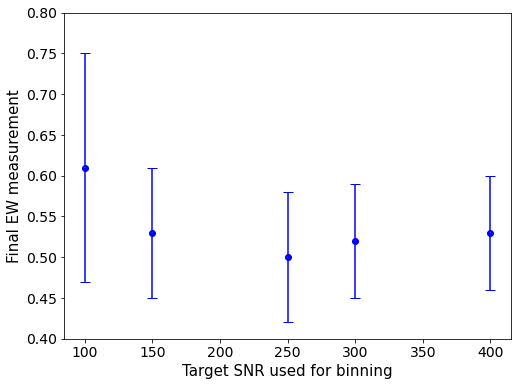

In [24]:
import numpy as np

import matplotlib.pyplot as plt
x=[100,150,250,300,400]
y=[0.61,0.53,0.50,0.52,0.53]
yerr=[0.14,0.08,0.08,0.07,0.07]

plt.figure(figsize=(8, 6))
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
scatter=plt.errorbar(x,y,yerr, fmt='o', c='Blue', capsize=5,zorder=1)
scatter=plt.scatter(x,y,yerr,zorder=2)
plt.ylim([0.4,0.8])
plt.savefig("EW_for_different_target_SNRs.pdf", bbox_inches='tight')
plt.xlabel("Target SNR used for binning",fontsize=15)
plt.ylabel("Final EW measurement",fontsize=15)

In [ ]:
matplotlib.pyplot.errorbar(x, y, yerr=None, xerr=None, fmt='', *, ecolor=None, elinewidth=None, capsize=None, barsabove=False, lolims=False, uplims=False, xlolims=False, xuplims=False, errorevery=1, capthick=None, data=None, **kwargs)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



na_rest=(5890+5896)/2
halpha=6562.8

SN_name="SN2010ev"
if SN_name=="SN2010ev":
    z=0.00921
    ra, dec = 156.370792, -39.830889
spectra=[]


for fname in sorted(glob.glob("./milky-way/outliers/*.npy")):
    w, f = np.load(fname, allow_pickle=True)
    spectra.append(f)

In [ ]:
EWs_Halpha = []
EWs_Na = []
EWs_Halpha_err = []
EWs_Na_err = []

for i in range(0,len(spectra)):
    out=EW_voronoi_bins(np.array([spectra[i]]), w, halpha*(1+z),v=400, KS=100, text=False,plots=False)
    EWs_Halpha.append(out[0][0])
    EWs_Halpha_err.append(out[1][0])

    out=EW_voronoi_bins(np.array([spectra[i]]), w, na_rest,v=400, KS=100, text=False,plots=True)
    EWs_Na.append(out[0][0])
    EWs_Na_err.append(out[1][0])

In [ ]:
plt.figure(figsize=(14, 12))
ratio = np.divide(EWs_Na,EWs_Na_err)
sc=plt.scatter(EWs_Na,EWs_Halpha,c=ratio,cmap='viridis',zorder=2)
plt.errorbar(EWs_Na,EWs_Halpha, yerr=EWs_Halpha_err,xerr=EWs_Na_err, alpha=0.5,fmt='o', c='Blue', capsize=5,zorder=1)

cbar = plt.colorbar(sc)
cbar.set_label("EWs_Na / EWs_Na_err", fontsize=15)
plt.xlabel("MW Na doublet EW",fontsize=20)
plt.ylabel("Host Halpha EW",fontsize=20)

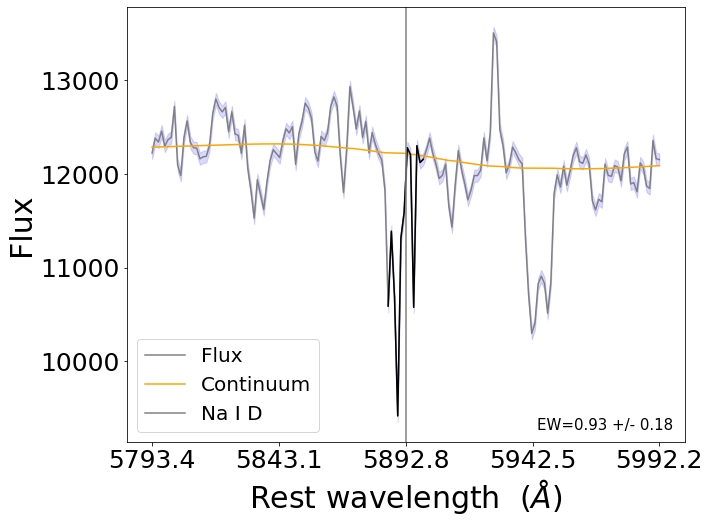

In [115]:
out=EW_voronoi_bins(np.array([spectra[11]]), w, na_rest,v=400, KS=100, text=False,plots=True)

Number of dips: 0


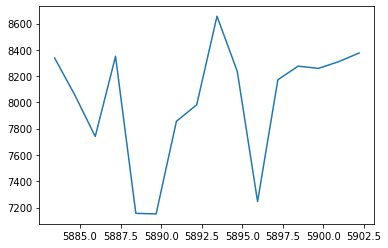

In [110]:
v=500
bound1=na_rest*(1-v/(3*10**5))
bound2=na_rest*(1+v/(3*10**5))

from scipy.signal import find_peaks
x_chopped,y_chopped=chop_data(w,y,bound1,bound2)
plt.plot(x_chopped,y_chopped)

inverted_flux = np.max(y) - y_chopped


peaks, properties = find_peaks(
    inverted_flux,
    prominence=0.05 * np.ptp(y),  # relative to the full flux range
    width=1                       # optional: ignore very narrow spikes
)

# Number of dips
num_dips = len(peaks)
print("Number of dips:", num_dips)


In [72]:
- REDO THIS PLOT WITH MORE POINTS
- plow ew vs voronoi bin but excluding the ones with 3 dips

SyntaxError: invalid syntax (109765389.py, line 1)

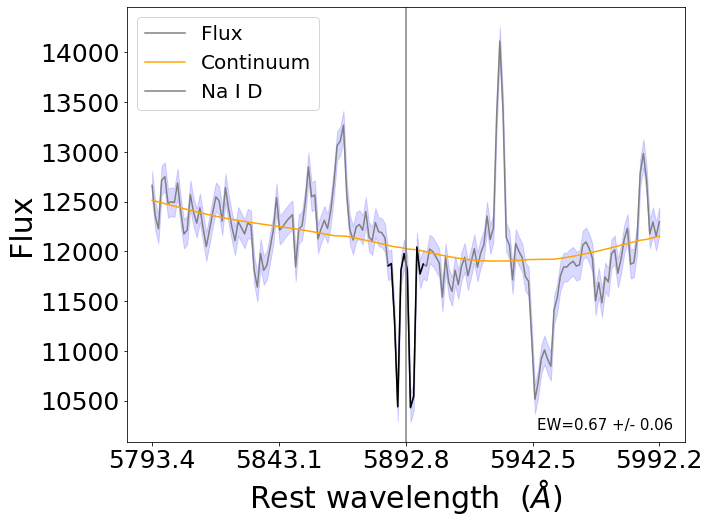


EW= 0.67  +/-  0.055362158208232475

Node separation =  139.96478873239437  Angstrom
SNR of the line is  12.131298688911595


([0.671614877286847], [0.055362158208232475], [7125.307418923861])

In [25]:
import numpy as np
import matplotlib.pyplot as plt


ew_val=0.67

na_rest=(5890+5896)/2
halpha=6562.8

SN_name="SN2010ev"
if SN_name=="SN2010ev":
    z=0.00921
    ra, dec = 156.370792, -39.830889


w,f = np.load("./milky-way/outliers/"+str(ew_val)+".npy")

EW_voronoi_bins(np.array([f]),w,na_rest,v=400,KS=100,plots=True)

array([4748.44238281, 4749.69238281, 4750.94238281, ..., 9345.94238281,
       9347.19238281, 9348.44238281])

In [ ]:
plot EW na vs EW Halpha

In [36]:
0 - window/continuum test for ellipse 

1 - this thing of 3 dips seems to happen to almost all outliers, does it happen to any of the good spectra?

2 - does halpha correlate with outlier mw na i d absorption?

3 - for the good EW bins, is d2/d1 constant?
4 - plot d2/d1 for all bins. and see if d2/d1 happens only for bins with outlying EW of na i D.


5- plot EW per voronoi bins but excluding lines with 3 components

is there correlation between high EW of Na i D and emission of halpha? then this could be a stellar contribution
Na I D outflow absorption. in a star forming region (check this, is halpha qutie large?). is halpah also showing a blueshiffted component in this bin only?

This is almost certainly a blueshifted Na I D absorption component from neutral gas in the host (outflow / streaming), not stellar absorption and not MW.

5886.0

In [14]:
to do:
    best window or continuum
    na incerteza de EW incluir o erro por estar a incluir varios espetros

SyntaxError: invalid syntax (1805529083.py, line 1)

In [40]:
5797*(1+z)

5850.39037

In [7]:
KSs=np.arange(20,300,20)
KSs

array([ 10,  30,  50,  70,  90, 110, 130, 150, 170, 190, 210, 230, 250,
       270, 290])

In [ ]:
plo